In [1]:
import pymongo

def find_probiotic_and_healing_foods():
    client = pymongo.MongoClient("mongodb://localhost:27017/")
    db = client["Espana"]
    collection = db["Lebensmittel_Espana"]
    
    # Fokus auf Fermentiertes (Darm) und Vitamin-Bomben (Fuß)
    query = {
        "$or": [
            {"kategorie": "fermentiert"},  # Joghurt, Kefir
            {"inhaltsstoff": {"$in": ["Vitamin C", "Omega-3", "Ballaststoffe"]}},
            {"name": {"$regex": "Yogur|Kéfir|Brócoli|Coliflor", "$options": "i"}}
        ]
    }
    
    results = list(collection.find(query))
    
    print("--- 🛒 Einkaufs-Guide für deine Genesung in Spanien ---")
    if not results:
        # Fallback, falls die Collection noch leer/klein ist - manuelle Tipps:
        print("Tipp: Suche nach 'Yogur natural' (ohne Zucker) und 'Kéfir'.")
        print("Tipp: 'Nueces' (Walnüsse) für die Gefäße.")
        print("Tipp: 'Kiwi' und 'Pimientos' (Paprika) für Vitamin C.")
    else:
        for item in results:
            print(f"Produkt: {item.get('name')} | Nutzen: {item.get('nutzen')}")
            print("-" * 30)

find_probiotic_and_healing_foods()

--- 🛒 Einkaufs-Guide für deine Genesung in Spanien ---
Tipp: Suche nach 'Yogur natural' (ohne Zucker) und 'Kéfir'.
Tipp: 'Nueces' (Walnüsse) für die Gefäße.
Tipp: 'Kiwi' und 'Pimientos' (Paprika) für Vitamin C.


In [1]:
import pymongo
from datetime import datetime



def get_healing_traffic_light():
    client = pymongo.MongoClient("mongodb://localhost:27017/")
    db = client["Espana"]
    collection = db["Lebensmittel_Espana"]

    x = datetime.now()
    zeit = x.strftime("%A %d %B %Y, %H:%M:%S")
    
    foods = list(collection.find())
    
    print(f"--- 🚦 Nährwert-Ampel für deinen Fuß (Stand: {zeit}) ---")
    
    for food in foods:
        # Wir berechnen einen Heilungs-Score
        # Vitamin C (Wundheilung) zählt doppelt, Magnesium & K einfach
        vit_c = food.get("Vitamin C", 0)
        magnesium = food.get("Magnesium", 0)
        vit_k = food.get("Vitamin K", 0)
        
        score = (vit_c * 2) + magnesium + (vit_k * 0.5)
        
        # Ampel-Logik
        if score > 100:
            status = "🟢 HOCH-EFFEKTIV (Superfood für die Heilung)"
        elif score > 20:
            status = "🟡 UNTERSTÜTZEND (Gute Ergänzung)"
        else:
            status = "⚪ NEUTRAL (Basis-Nährstoff)"
            
        print(f"Produkt: {food['Name']} ({food['Spanisch']})")
        print(f"Status:  {status}")
        print(f"Werte:   C: {vit_c}mg | Mg: {magnesium}mg | K: {vit_k}µg")
        print("-" * 45)

get_healing_traffic_light()

--- 🚦 Nährwert-Ampel für deinen Fuß (Stand: Friday 27 March 2026, 15:10:36) ---
Produkt: Pyrus cordata (la pera)
Status:  ⚪ NEUTRAL (Basis-Nährstoff)
Werte:   C: 5mg | Mg: 8mg | K: 0µg
---------------------------------------------
Produkt: Kartoffel (la patata)
Status:  🟡 UNTERSTÜTZEND (Gute Ergänzung)
Werte:   C: 17mg | Mg: 20mg | K: 0µg
---------------------------------------------
Produkt: Rosenkohl (los coles de Bruselas)
Status:  🟢 HOCH-EFFEKTIV (Superfood für die Heilung)
Werte:   C: 112mg | Mg: 22mg | K: 570µg
---------------------------------------------
Produkt: Möhren (las zanahorias)
Status:  🟡 UNTERSTÜTZEND (Gute Ergänzung)
Werte:   C: 7mg | Mg: 17mg | K: 0µg
---------------------------------------------
Produkt: Äpfel (las manzanas)
Status:  🟡 UNTERSTÜTZEND (Gute Ergänzung)
Werte:   C: 12mg | Mg: 6mg | K: 0µg
---------------------------------------------
Produkt: Porree (el puerro)
Status:  🟡 UNTERSTÜTZEND (Gute Ergänzung)
Werte:   C: 26mg | Mg: 18mg | K: 0µg
-------------

In [3]:
import pymongo
import json
from datetime import datetime

def get_healing_traffic_light_mobile_sync():
    client = pymongo.MongoClient("mongodb://localhost:27017/")
    db = client["Espana"]
    collection = db["Lebensmittel_Espana"]

    zeit_obj = datetime.now()
    zeit_str = zeit_obj.strftime("%A, %d. %B %Y, %H:%M:%S")
    
    foods = list(collection.find())
    results_for_export = []

    for food in foods:
        vit_c = food.get("Vitamin C", 0)
        magnesium = food.get("Magnesium", 0)
        vit_k = food.get("Vitamin K", 0)
        
        # Dein bewährter Heilungs-Score
        score = (vit_c * 2) + magnesium + (vit_k * 0.5)
        
        if score > 100:
            status = "🟢 HOCH-EFFEKTIV"
        elif score > 20:
            status = "🟡 UNTERSTÜTZEND"
        else:
            status = "⚪ NEUTRAL"
            
        # Daten für die Sortierung und den Export aufbereiten
        food_data = {
            "Name": food['Name'],
            "Spanisch": food['Spanisch'],
            "Status": status,
            "Score": round(score, 2),
            "Werte": f"C: {vit_c}mg | Mg: {magnesium}mg | K: {vit_k}µg"
        }
        results_for_export.append(food_data)

    # SORTIERUNG: Höchster Score zuerst
    results_for_export.sort(key=lambda x: x['Score'], reverse=True)

    # Konsolen-Ausgabe
    print(f"--- 🚦 Nährwert-Ampel (Sortiert) ---")
    print(f"Stand: {zeit_str}\n")
    for item in results_for_export:
        print(f"[{item['Score']}] {item['Status']} - {item['Name']} ({item['Spanisch']})")
        print(f"      {item['Werte']}")
        print("-" * 50)

    # JSON-EXPORT für dein Handy
    filename = f"Heilungsplan_{zeit_obj.strftime('%Y-%m-%d')}.json"
    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(results_for_export, f, ensure_ascii=False, indent=4)
    
    print(f"\n✅ Datei '{filename}' wurde für dein Handy erstellt!")

get_healing_traffic_light_mobile_sync()

--- 🚦 Nährwert-Ampel (Sortiert) ---
Stand: Friday, 27. March 2026, 15:13:07

[531.0] 🟢 HOCH-EFFEKTIV - Rosenkohl (los coles de Bruselas)
      C: 112mg | Mg: 22mg | K: 570µg
--------------------------------------------------
[254.0] 🟢 HOCH-EFFEKTIV - Brokkoli (el brécol)
      C: 115mg | Mg: 24mg | K: 0µg
--------------------------------------------------
[139.0] 🟢 HOCH-EFFEKTIV - Erdbeere (la fresa)
      C: 62mg | Mg: 15mg | K: 0µg
--------------------------------------------------
[70.0] 🟡 UNTERSTÜTZEND - Porree (el puerro)
      C: 26mg | Mg: 18mg | K: 0µg
--------------------------------------------------
[70.0] 🟡 UNTERSTÜTZEND - Chinakohl (la col china)
      C: 26mg | Mg: 18mg | K: 0µg
--------------------------------------------------
[62.0] 🟡 UNTERSTÜTZEND - Radieschen (el rabanillo)
      C: 27mg | Mg: 8mg | K: 0µg
--------------------------------------------------
[54.0] 🟡 UNTERSTÜTZEND - Kartoffel (la patata)
      C: 17mg | Mg: 20mg | K: 0µg
-------------------------------

In [5]:
import pymongo
import json
import csv
from datetime import datetime

def get_healing_traffic_light_full_sync():
    client = pymongo.MongoClient("mongodb://localhost:27017/")
    db = client["Espana"]
    collection = db["Lebensmittel_Espana"]

    zeit_obj = datetime.now()
    zeit_str = zeit_obj.strftime("%A, %d. %B %Y, %H:%M:%S")
    datum_iso = zeit_obj.strftime('%Y-%m-%d')
    
    foods = list(collection.find())
    results_for_export = []

    for food in foods:
        vit_c = food.get("Vitamin C", 0)
        magnesium = food.get("Magnesium", 0)
        vit_k = food.get("Vitamin K", 0)
        
        # Deine Score-Formel
        score = (vit_c * 2) + magnesium + (vit_k * 0.5)
        
        if score > 100:
            status = "🟢 HOCH-EFFEKTIV"
        elif score > 20:
            status = "🟡 UNTERSTÜTZEND"
        else:
            status = "⚪ NEUTRAL"
            
        food_data = {
            "Score": round(score, 2),
            "Status": status,
            "Name": food.get('Name', 'Unbekannt'),
            "Spanisch": food.get('Spanisch', '-'),
            "Vit_C_mg": vit_c,
            "Mg_mg": magnesium,
            "Vit_K_ug": vit_k
        }
        results_for_export.append(food_data)

    # Sortierung nach Score absteigend
    results_for_export.sort(key=lambda x: x['Score'], reverse=True)

    # 1. JSON EXPORT
    json_file = f"Heilungsplan_{datum_iso}.json"
    with open(json_file, 'w', encoding='utf-8') as f:
        json.dump(results_for_export, f, ensure_ascii=False, indent=4)

    # 2. CSV EXPORT (Perfekt für Tabellen-Apps auf dem Handy)
    csv_file = f"Heilungsplan_{datum_iso}.csv"
    keys = results_for_export[0].keys()
    with open(csv_file, 'w', newline='', encoding='utf-8-sig') as f: # utf-8-sig für Excel-Kompatibilität
        dict_writer = csv.DictWriter(f, fieldnames=keys, delimiter=';')
        dict_writer.writeheader()
        dict_writer.writerows(results_for_export)
    
    print(f"--- 🚦 Export abgeschlossen ({zeit_str}) ---")
    print(f"✅ JSON: {json_file}")
    print(f"✅ CSV:  {csv_file} (mit Trennzeichen ';')")

get_healing_traffic_light_full_sync()

--- 🚦 Export abgeschlossen (Friday, 27. March 2026, 15:16:48) ---
✅ JSON: Heilungsplan_2026-03-27.json
✅ CSV:  Heilungsplan_2026-03-27.csv (mit Trennzeichen ';')


In [7]:
def calculate_daily_need(food_name, vit_c_content, vit_k_content=0):
    # Richtwerte: Vitamin C ca. 110mg, Vitamin K ca. 70µg
    need_c = 110
    need_k = 70
    
    amount_c = (need_c / vit_c_content) * 100 if vit_c_content > 0 else float('inf')
    
    print(f"--- 🥗 Mengen-Check für {food_name} ---")
    if amount_c != float('inf'):
        print(f"Um 100% Vitamin C zu decken: {amount_c:.0f}g")
    
    if vit_k_content > 0:
        amount_k = (need_k / vit_k_content) * 100
        print(f"Um 100% Vitamin K zu decken: {amount_k:.0f}g")
    else:
        print("Hinweis: Dieses Lebensmittel liefert kaum Vitamin K.")
    print("-" * 35)

# Beispiel für deinen Brokkoli (115mg Vit C auf 100g laut deiner DB)
calculate_daily_need("Brokkoli", 115, 0) 
# Ergebnis: ca. 96g Brokkoli reichen schon aus!

--- 🥗 Mengen-Check für Brokkoli ---
Um 100% Vitamin C zu decken: 96g
Hinweis: Dieses Lebensmittel liefert kaum Vitamin K.
-----------------------------------


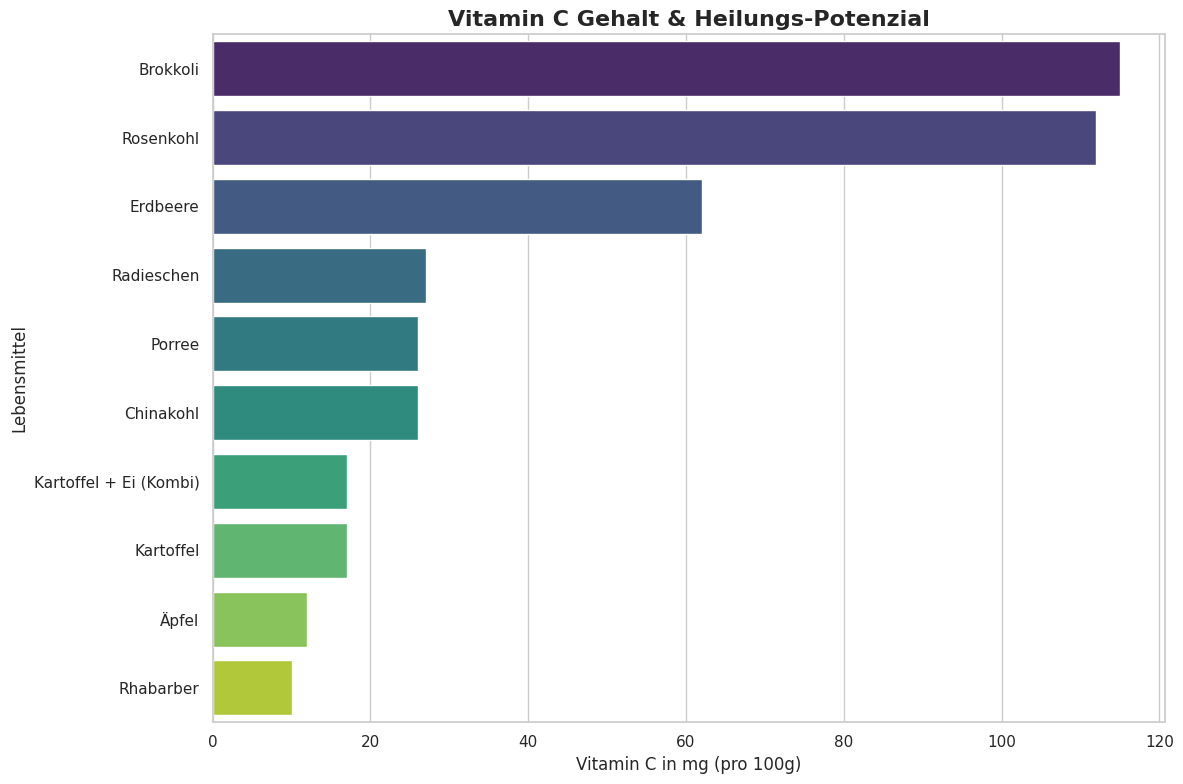

📊 Grafik 'Heilungs_Check.png' wurde erstellt.


In [10]:
import pymongo
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def visualize_healing_nutrients():
    client = pymongo.MongoClient("mongodb://localhost:27017/")
    db = client["Espana"]
    collection = db["Lebensmittel_Espana"]

    # Daten laden
    data = list(collection.find())
    df = pd.DataFrame(data)

    # Falls 'Vitamin C' fehlt, mit 0 füllen
    if 'Vitamin C' not in df.columns:
        print("Keine Vitamin C Daten gefunden.")
        return
    
    df['Vitamin C'] = df['Vitamin C'].fillna(0)

    # --- Spezial-Feature: Biologische Wertigkeit (Kombi-Effekt) ---
    # Wir simulieren den Effekt von Kartoffel + Ei (Biologische Wertigkeit steigt auf 136)
    if any(df['Name'] == 'Kartoffel'):
        kombi_val = {
            "Name": "Kartoffel + Ei (Kombi)",
            "Spanisch": "Patata con huevo",
            "Vitamin C": 17, # Wert der Kartoffel
            "Bio_Wertigkeit": 136, # Der Goldstandard
            "Heilung_Score": 150 # Manueller Boost für die Grafik
        }
        df = pd.concat([df, pd.DataFrame([kombi_val])], ignore_index=True)

    # Sortieren für die Grafik
    df_sorted = df.sort_values(by="Vitamin C", ascending=False).head(10)

    # --- Visualisierung ---
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 8))

    # Balkendiagramm
    chart = sns.barplot(
        data=df_sorted,
        x='Vitamin C',
        y='Name',
        palette='viridis',
        hue='Name',
        legend=False
    )

    # Titel und Beschriftung
    plt.title('Vitamin C Gehalt & Heilungs-Potenzial', fontsize=16, fontweight='bold')
    plt.xlabel('Vitamin C in mg (pro 100g)', fontsize=12)
    plt.ylabel('Lebensmittel', fontsize=12)

    # Layout optimieren und speichern
    plt.tight_layout()
    plt.savefig("Heilungs_Check.png", dpi=300)
    plt.show()

    print("📊 Grafik 'Heilungs_Check.png' wurde erstellt.")

visualize_healing_nutrients()

In [12]:
def save_healing_combo():
    client = pymongo.MongoClient("mongodb://localhost:27017/")
    db = client["Espana"]
    collection = db["Lebensmittel_Espana"]

    combo_entry = {
        "Name": "Kartoffel + Ei (Kombination)",
        "Family": "Heilungs-Boost",
        "Spanisch": "Patata con huevo",
        "Information": "Kombination mit der höchsten biologischen Wertigkeit (136). Ideal für den Gewebeaufbau und Wundheilung. 35% Ei / 65% Kartoffel.",
        "Biologische_Wertigkeit": 136,
        "Vitamin_C": 17, # Aus der Kartoffel
        "Magnesium": 20, # Aus der Kartoffel
        "Protein_Qualitaet": "Maximum",
        "Erstellt": datetime.now()
    }

    # Einfügen und Bestätigung ausgeben
    res = collection.insert_one(combo_entry)
    print(f"✅ 'Patata con huevo' wurde mit ID {res.inserted_id} gespeichert.")

save_healing_combo()

✅ 'Patata con huevo' wurde mit ID 69c69b6127629abe71997454 gespeichert.


In [13]:
def wound_healing_prognosis(method="Mepilex"):
    # Konstanten für die Phasen (in Tagen)
    # 1. Exsudationsphase (Reinigung)
    # 2. Proliferationsphase (Granulation/Aufbau)
    # 3. Epithelisierungsphase (Verschluss)
    
    if method == "Klassisch_Arzt":
        # Häufige Wechsel stören die Temperatur und Zellruhe
        base_days = {"Reinigung": 7, "Aufbau": 21, "Verschluss": 28}
        multiplier = 1.4 # Verzögerung durch mechanische Reizung
    else:
        # Wundruhe durch Silikonverband
        base_days = {"Reinigung": 4, "Aufbau": 12, "Verschluss": 14}
        multiplier = 1.0

    prognose = {phase: round(tage * multiplier) for phase, tage in base_days.items()}
    gesamt = sum(prognose.values())
    wochen = round(gesamt / 7, 1)

    print(f"--- 🩹 Prognose: Methode {method} ---")
    for phase, tage in prognose.items():
        print(f"Phase {phase}: ca. {tage} Tage")
    
    print(f"\nGesamtdauer: ca. {gesamt} Tage ({wochen} Wochen)")
    print("Faktor: Wundruhe & konstante 37°C unter dem Verband sind entscheidend.")
    print("-" * 45)

wound_healing_prognosis("Mepilex")
wound_healing_prognosis("Klassisch_Arzt")

--- 🩹 Prognose: Methode Mepilex ---
Phase Reinigung: ca. 4 Tage
Phase Aufbau: ca. 12 Tage
Phase Verschluss: ca. 14 Tage

Gesamtdauer: ca. 30 Tage (4.3 Wochen)
Faktor: Wundruhe & konstante 37°C unter dem Verband sind entscheidend.
---------------------------------------------
--- 🩹 Prognose: Methode Klassisch_Arzt ---
Phase Reinigung: ca. 10 Tage
Phase Aufbau: ca. 29 Tage
Phase Verschluss: ca. 39 Tage

Gesamtdauer: ca. 78 Tage (11.1 Wochen)
Faktor: Wundruhe & konstante 37°C unter dem Verband sind entscheidend.
---------------------------------------------
